<a href="https://colab.research.google.com/github/zeegy99/Quant_Backtesting_Models/blob/main/MACD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overarching Strategy:** The Moving Average Convergence Divergence (MACD) is a technical analysis tool that uses momentum to find opportunities to buy/sell. Academic Papers like Jegadesh & Titman (Implemented in a different repo, soon to be linked) have proved that momentum still works and I wanted to extend this to see if MACD also produces returns. We are looking at the exponential moving average and whenever it flips from positive to negative we sell, and when it flips from negative sentiment to positive sentiment we buy.

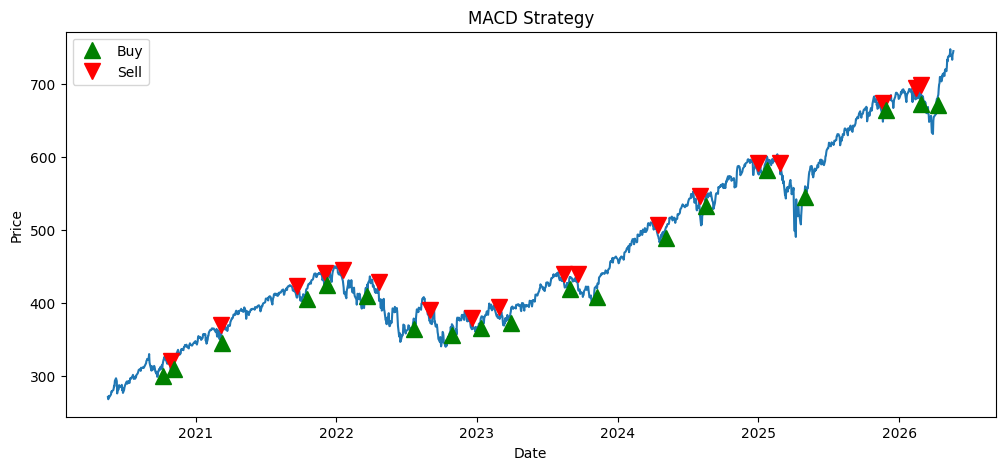

**Some Assumptions that are made: **

1. Buying and Selling are cut off such that they are 1:1 to not deal with the implications of Shorting & costs.  
2. Starting with 10,000 of capital, on a buy signal you will buy as much as you can and sell everything.

TODO/Additional Considerations
1. Adjusting the buy signal based on duration/intensity of switches
2. Trading costs are not incorporated
3. I assume we can easily short stocks without problem, and that the eventual buy pair cancels out the short leg.
4. How does this strategy perform during times of intense volatility?


**Findings:** During longer periods or periods of general growth, the sharpe and max drawdown significantly outperforms The s&p500. However, cumulative returns are less because we are not in the market during extended periods of time. Combined with a Bond/Money Market/ETF strategy this easily outperforms


However, during times of turbulence, MACD underperforms. [1999-2002, Cumulative return of -19.33% vs. -14.89%, Sharpe: -11.33 vs -0.15]

In [88]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import math
import requests

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def run_MACD(stock, start, end, plot=True):

  start = start
  end = end
  ticker = stock



  def find_rfr(date):
    url = "https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v2/accounting/od/avg_interest_rates"

    params = {
        "filter": f"record_date:lte:{date}",
        "fields": "record_date,security_desc,avg_interest_rate_amt",
        "sort": "-record_date",
        "page[size]": 100,
    }

    r = requests.get(url, params=params)
    data = r.json()


    return float(data['data'][0]['avg_interest_rate_amt'])/100


  def MACD(stock, start, end):
      #12-period EMA - 26-period EMA
      result = EMA(stock, 12, start, end) - EMA(stock, 26, start, end)
      return result


  def EMA(stock, period, start, end):

    #EMA Calculations based on articles
    df = yf.download(stock, start, end)
    df['SMA'] = df['Close'].rolling(period).mean()
    mult = 2 / (period + 1)

    ema_values = [np.nan] * len(df)

    for i in range(len(df)):
        close = df['Close'].iloc[i].item()
        sma   = df['SMA'].iloc[i].item()
        if math.isnan(sma):
            continue
        elif math.isnan(ema_values[i - 1]):
            ema_values[i] = sma
        else:
            ema_values[i] = ema_values[i - 1] * (1 - mult) + close * mult

    df['EMA'] = ema_values
    return df['EMA']

  def plot_MACD(stock, start, end):
    #Plotting what MACD is
    df = MACD(stock, start, end).to_frame()
    df.name='MACD'

    df = df.rename(columns={'EMA': 'MACD'})

    plt.figure(figsize=(15, 7))
    plt.plot(df.index, df['MACD'])
    plt.title('MACD Graph')
    plt.show()

  def buy_sell_strategy(stock, start, end):
    df = MACD(stock, start, end).to_frame()
    df.name='MACD'

    df = df.rename(columns={'EMA': 'MACD'})
    #Cleaning MACD data so that we can determine when to buy/sell
    df['Clean'] = df['MACD'].fillna(-10)
    df['Buy'] = np.where(df['Clean'] > 0, 1, 0)

    Buy_list = []
    Sell_list = []
    in_position = False

    for i in range(len(df)):
        macd_today = df['MACD'].iloc[i]
        macd_yesterday = df['MACD'].iloc[i - 1]

        if math.isnan(macd_today) or math.isnan(macd_yesterday):
            continue
        '''Moving This section towards Equity plot because it is not a fundamental part of the strategy '''
        # if in_position == False:
        #   #Not taking position, Assume we take the risk free rate.

        if macd_today > 0 and macd_yesterday <= 0 and not in_position:
            Buy_list.append(i)
            in_position = True

        elif macd_today < 0 and macd_yesterday >= 0 and in_position:
            Sell_list.append(i)
            in_position = False
    return (Buy_list, Sell_list)

  def plot_buy_sell_strategy(Buy_list, Sell_list, ticker, start, end):
    fig, ax = plt.subplots(figsize=(12, 5))

    baseline = yf.download(ticker, start, end)
    ax.plot(baseline.index, baseline['Close'])

    buy_dates  = baseline.index[Buy_list]
    buy_prices = baseline['Close'].iloc[Buy_list]

    sell_dates = baseline.index[Sell_list]
    sell_prices = baseline['Close'].iloc[Sell_list]


    ax.plot(buy_dates, buy_prices - 15, '^', markersize=12, color='green', zorder=5, label='Buy')
    ax.plot(sell_dates, sell_prices + 15, 'v', markersize=12, color='red', label='Sell')
    plt.legend()
    plt.title("MACD Strategy")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.show()


  def calculate_equity(Buy_list, Sell_list, ticker, start, end):
    baseline = yf.download(ticker, start, end)

    capital = 10000  # starting capital, arbitrary.
    #Assumptions is that you are max-buying.

    equity = [capital]
    lesser = min(len(Buy_list), len(Sell_list))
    for i in range(lesser):
        buy_price  = baseline['Close'].iloc[Buy_list[i]].item()
        sell_price = baseline['Close'].iloc[Sell_list[i]].item()

        shares = capital // buy_price


        capital += shares * (sell_price - buy_price)
        equity.append(capital)


    equity = np.array(equity)
    total_return = (equity[-1] - equity[0]) / equity[0]
    trade_returns = np.diff(equity) / equity[:-1]

    years_implemented = (end - start).days / 365.25

    num_trades_per_year = lesser/years_implemented
    rfr = 0.05
    rfr_per_trade = rfr / num_trades_per_year


    sharpe = (trade_returns.mean() - rfr_per_trade) / trade_returns.std() * np.sqrt(num_trades_per_year)

    #Max Drawdown
    prev_mx = equity[0]
    mx_drawdown = 0
    for i in range(1, len(equity)):
      if equity[i] > prev_mx:
        prev_mx = equity[i]
      else:
        mx_drawdown = max(mx_drawdown, (prev_mx - equity[i]) / prev_mx)

    return (equity, total_return, sharpe, mx_drawdown)

  '''Another Strategy'''
  def calculate_equity_rfr(Buy_list, Sell_list, ticker, start, end):
    baseline = yf.download(ticker, start, end)
    close = baseline['Close'].squeeze()
    capital = 10000  # starting capital, arbitrary.
    daily_returns = []
    daily_rf = 0.05/365


    start_date_str = baseline.index[0].strftime("%Y-%m-%d")
    annual_rf = find_rfr(start_date_str)
    daily_rf = annual_rf / 365



    #Assumptions is that you are max-buying.


    lesser = min(len(Buy_list), len(Sell_list))
    for i in range(lesser):
        buy_idx  = Buy_list[i]
        sell_idx = Sell_list[i]

        # --- Days out of market before this trade ---
        if i == 0:
            prev_sell = 0
        else:
            prev_sell = Sell_list[i - 1]

        cash_days = buy_idx - prev_sell
        for _ in range(cash_days):
            daily_returns.append(daily_rf)  # earning risk-free while waiting

        # --- Days in the trade ---
        prices = baseline['Close'].iloc[buy_idx:sell_idx + 1]


        trade_daily = prices.pct_change().dropna()
        a = trade_daily.values.tolist()

        for k in range(len(a)):

          daily_returns.append(a[k][0])

        # daily_returns.extend(trade_daily.values.tolist())

    daily_returns = np.array(daily_returns)

    # --- Equity curve from daily returns ---
    equity = 10000 * np.cumprod(1 + daily_returns)
    equity = np.insert(equity, 0, 10000)

    total_return  = (equity[-1] - equity[0]) / equity[0]
    rolling_max   = np.maximum.accumulate(equity)
    max_drawdown  = ((equity - rolling_max) / rolling_max).min()

    # Sharpe is now correct — all daily returns, same basis as SPY
    sharpe = (daily_returns.mean() - daily_rf) / daily_returns.std() * np.sqrt(252)


    print(f"Final Capital:       ${equity[-1]:,.2f}")
    print(f"Total Return:        {total_return:.2%}")
    print(f"Sharpe (strategy):   {sharpe:.2f}")
    print(f"Max Drawdown:        {max_drawdown:.2%}")

    return (equity, total_return, sharpe, mx_drawdown)


  def plot_equity(equity):
    #Final Graph
    plt.plot(equity)
    plt.title('Equity Curve')
    plt.xlabel('Trade #')
    plt.ylabel('Capital ($)')
    plt.show()

  #Comparison to SPY over timeframe
  def spy(start, end):
    spy = yf.download('SPY', start, end)

    spy_return = (spy['Close'].iloc[-1].item() - spy['Close'].iloc[0].item()) / spy['Close'].iloc[0].item()

    spy_daily_returns = spy['Close'].pct_change().dropna()
    spy_sharpe = ((spy_daily_returns.mean() - 0.05/252) / spy_daily_returns.std() * np.sqrt(252)).item()

    return (spy_return, spy_sharpe)

  def hold_stock(start, end):
    baseline = yf.download(ticker, start, end)
    base_return = (baseline['Close'].iloc[-1].item() - baseline['Close'].iloc[0].item()) / baseline['Close'].iloc[0].item()

    base_daily_returns = baseline['Close'].pct_change().dropna()

    base_sharpe = ((base_daily_returns.mean() - 0.05/252) / base_daily_returns.std() * np.sqrt(252)).item()

    return (base_daily_returns, base_sharpe)


  Buy_list, Sell_list = buy_sell_strategy(ticker, start, end)
  equity, total_return, sharpe, mx_drawdown = calculate_equity(Buy_list, Sell_list, ticker, start, end)
  spy_return, spy_sharpe = spy(start, end)
  equity2, total_return2, sharpe2, mx_drawdown2 = calculate_equity_rfr(Buy_list, Sell_list, ticker, start, end)
  plot_equity(equity2)

  base_daily_returns, base_sharpe = hold_stock(start, end)

  if plot:
    plot_MACD(ticker, start, end)
    plot_buy_sell_strategy(Buy_list, Sell_list, ticker, start, end)
    plot_equity(equity)

  print(f"SPY Return: {spy_return:.2%}, Strategy Return {total_return:.2%}, Strategy With RFR Return {total_return2:.2%}")
  print(f"SPY Sharpe: {spy_sharpe:.2f}, Strategy sharpe {sharpe:.2f}, Strategy with RFR Sharpe: {sharpe2:.2f}")

  return (total_return, sharpe, base_daily_returns, base_sharpe)














/tmp/ipykernel_2207/113041713.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/113041713.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/113041713.py:133: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/113041713.py:253: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/113041713.py:177: FutureWarning: YF.download() has changed argument auto_adjust de

This is buy list: [34, 168, 268, 327, 355, 481, 602, 623, 706, 861, 896, 968], 
 This is sell list: [101, 248, 305, 347, 446, 590, 618, 705, 841, 894, 924, 989]
this is daily_rf 6.567123287671233e-05
Final Capital:       $15,545.99
Total Return:        55.46%
Sharpe (strategy):   0.86
Max Drawdown:        -11.95%
plot new


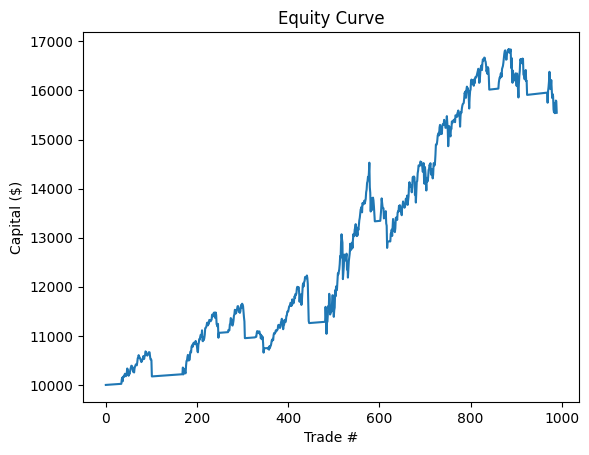

/tmp/ipykernel_2207/113041713.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/113041713.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


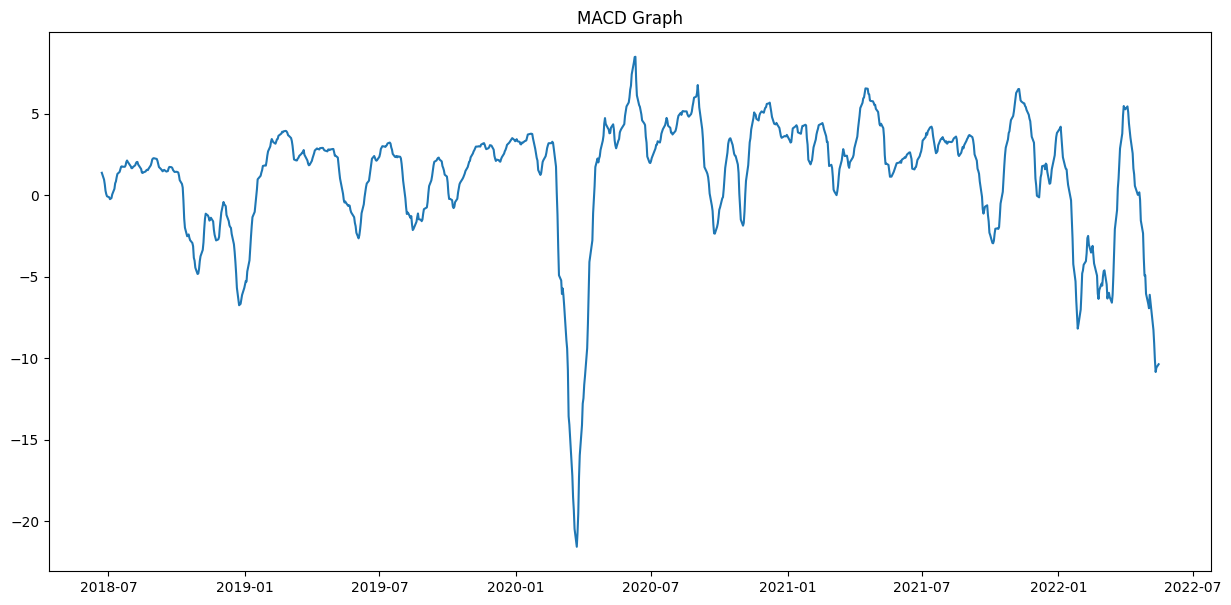

/tmp/ipykernel_2207/113041713.py:113: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


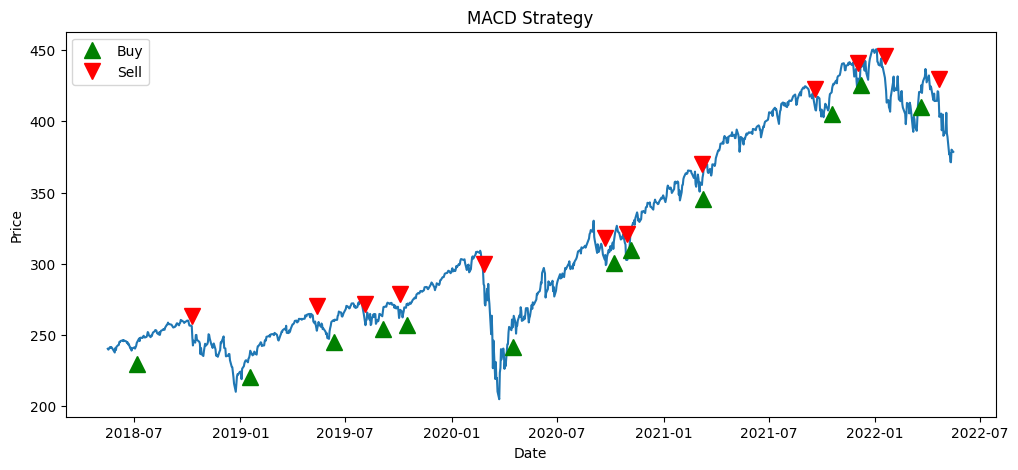

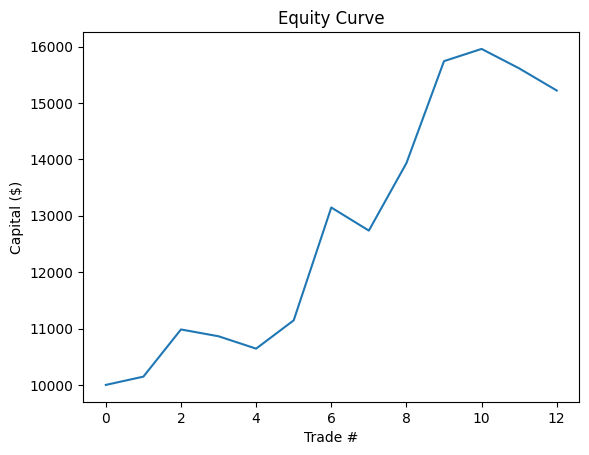

SPY Return: 57.50%, Strategy Return 52.21%, Strategy With RFR Return 55.46%
SPY Sharpe: 0.41, Strategy sharpe 0.55, Strategy with RFR Sharpe: 0.86


(np.float64(0.5220899215698243), np.float64(0.5484015797047072))

In [80]:
ticker = 'SPY'
start = datetime(2018, 5, 17)
end = datetime(2022, 5, 17)
run_MACD(ticker, start, end)

/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:133: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:253: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:177: FutureWarning: YF.download() has changed argument auto_adju

Final Capital:       $33,801.23
Total Return:        238.01%
Sharpe (strategy):   1.41
Max Drawdown:        -24.28%


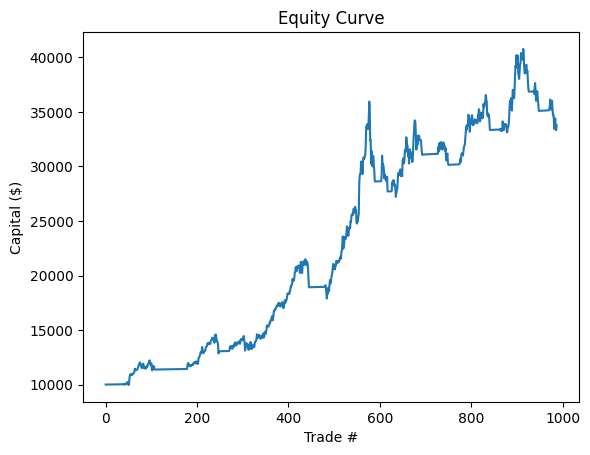

/tmp/ipykernel_2207/2163015723.py:263: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed

SPY Return: 57.50%, Strategy Return 230.62%, Strategy With RFR Return 238.01%
SPY Sharpe: 0.41, Strategy sharpe 1.04, Strategy with RFR Sharpe: 1.41



/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:133: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:253: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:177: FutureWarning: YF.download() has changed argument auto_adj

Final Capital:       $15,545.99
Total Return:        55.46%
Sharpe (strategy):   0.86
Max Drawdown:        -11.95%


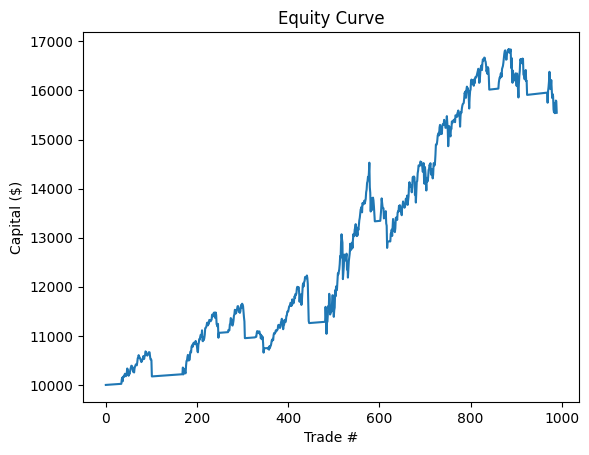

/tmp/ipykernel_2207/2163015723.py:263: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


SPY Return: 57.50%, Strategy Return 52.21%, Strategy With RFR Return 55.46%
SPY Sharpe: 0.41, Strategy sharpe 0.55, Strategy with RFR Sharpe: 0.86


/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:133: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:253: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:177: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


Final Capital:       $91,915.53
Total Return:        819.16%
Sharpe (strategy):   1.34
Max Drawdown:        -33.74%


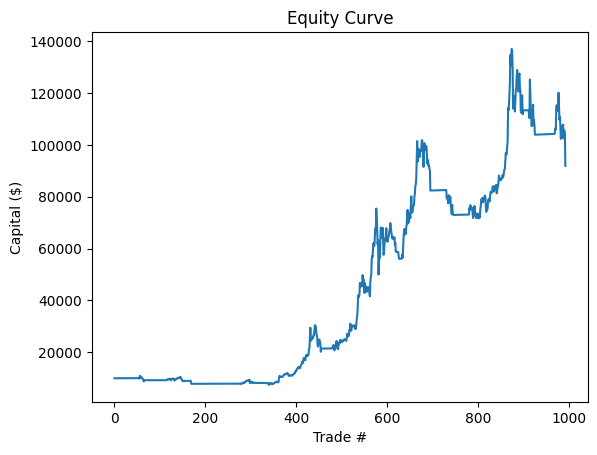

/tmp/ipykernel_2207/2163015723.py:263: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed

SPY Return: 57.50%, Strategy Return 794.01%, Strategy With RFR Return 819.16%
SPY Sharpe: 0.41, Strategy sharpe 0.80, Strategy with RFR Sharpe: 1.34



/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:133: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:253: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2207/2163015723.py:177: FutureWarning: YF.download() has changed argument auto_adj

Final Capital:       $19,730.03
Total Return:        97.30%
Sharpe (strategy):   0.62
Max Drawdown:        -39.04%


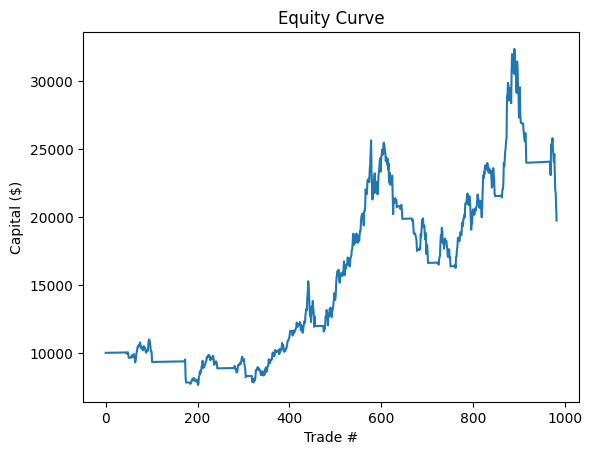

/tmp/ipykernel_2207/2163015723.py:263: FutureWarning: YF.download() has changed argument auto_adjust default to True
  baseline = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed

SPY Return: 57.50%, Strategy Return 93.07%, Strategy With RFR Return 97.30%
SPY Sharpe: 0.41, Strategy sharpe 0.42, Strategy with RFR Sharpe: 0.62


In [90]:
testing_world = ['AAPL', 'SPY', 'TSLA', 'NVDA']
start = datetime(2018, 5, 17)
end = datetime(2022, 5, 17)
for i in testing_world:
  a, b, c, d = run_MACD(i, start, end, plot=False)
  # print(a, b, c, d)